# Cheer Scoring Analysis | Findings & Visuals

## Purpose

This notebook translates the technical analysis in `01_scoring_eda.ipynb`
into clear visuals and practical findings for cheer coaches and gym owners.

Each visual will answer one question, explain what the data shows in plain
English, and identify any important limitations.

The goal is to communicate observed scoring and placement patterns—not to
claim that a particular training change will guarantee a better placement.

## Visual 1: Which scoring categories show up most consistently across levels?

In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "season_2026_all_levels_performances.csv"

print("Project root:", PROJECT_ROOT)
print("Master dataset exists:", DATA_PATH.exists())

Matplotlib is building the font cache; this may take a moment.


Project root: /Users/alecheffron/cheer-score-analysis
Master dataset exists: True


In [3]:
category_frequency = pd.DataFrame({
    "category": [
        "Stunt execution",
        "Pyramid difficulty",
        "Show",
        "Pyramid execution",
        "Standing tumbling execution",
        "Routine composition (RC)",
        "Running tumbling execution",
        "Formations & transitions",
        "Toss execution",
    ],
    "levels_in_top_five": [7, 6, 5, 5, 4, 4, 2, 1, 1],
})

print(category_frequency.to_string(index=False))

                   category  levels_in_top_five
            Stunt execution                   7
         Pyramid difficulty                   6
                       Show                   5
          Pyramid execution                   5
Standing tumbling execution                   4
   Routine composition (RC)                   4
 Running tumbling execution                   2
   Formations & transitions                   1
             Toss execution                   1


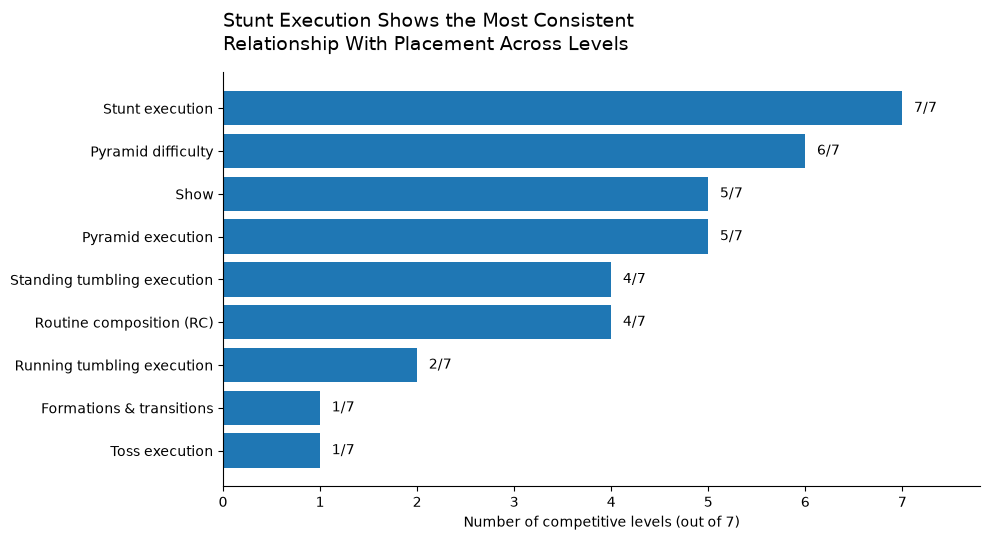

In [4]:
fig, ax = plt.subplots(figsize=(10, 5.5))

bars = ax.barh(
    category_frequency["category"],
    category_frequency["levels_in_top_five"],
)

ax.invert_yaxis()
ax.set_xlim(0, 7.8)
ax.set_xticks(range(0, 8))
ax.set_xlabel("Number of competitive levels (out of 7)")
ax.set_title(
    "Stunt Execution Shows the Most Consistent\n"
    "Relationship With Placement Across Levels",
    loc="left",
    fontsize=14,
    pad=16,
)

for bar in bars:
    ax.text(
        bar.get_width() + 0.12,
        bar.get_y() + bar.get_height() / 2,
        f"{int(bar.get_width())}/7",
        va="center",
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
plt.show()

**What this shows:** Stunt execution appeared among the five strongest
conditional placement relationships at all seven levels. Pyramid difficulty
appeared at six levels.

**How to read it:** Each bar counts the number of levels where a category
appeared in the top five based on its average model coefficient. This is a
measure of consistency across levels—not the amount a team's placement would
improve by raising that score.

## Visual 2: How do deductions relate to winning?

In [7]:
field_cols = ["competition_id", "level", "division_id", "round"]

df["field_size"] = (
    df.groupby(field_cols)["rank"]
    .transform("size")
)

eligible = df[df["field_size"] >= 3].copy()

eligible["deduction_group"] = eligible["deductions"].gt(0).map({
    False: "No deductions",
    True: "One or more deductions",
})

win_rates = (
    eligible.groupby("deduction_group")
    .agg(
        performances=("rank", "size"),
        wins=("rank", lambda ranks: (ranks == 1).sum()),
    )
    .reset_index()
)

win_rates["win_rate_pct"] = (
    100 * win_rates["wins"] / win_rates["performances"]
)

print(win_rates.to_string(index=False))

       deduction_group  performances  wins  win_rate_pct
         No deductions         12127  3220     26.552321
One or more deductions          9853   882      8.951588


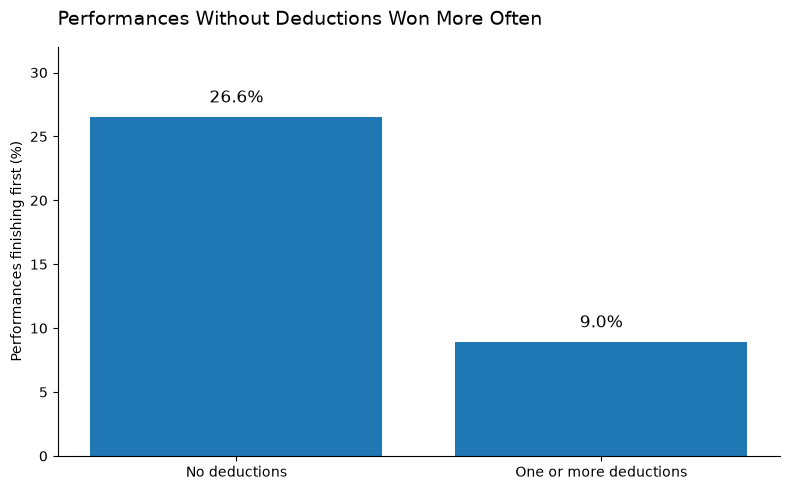

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    win_rates["deduction_group"],
    win_rates["win_rate_pct"],
)

ax.set_ylim(0, 32)
ax.set_ylabel("Performances finishing first (%)")
ax.set_title(
    "Performances Without Deductions Won More Often",
    loc="left",
    fontsize=14,
    pad=16,
)

for bar, rate in zip(bars, win_rates["win_rate_pct"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{rate:.1f}%",
        ha="center",
        va="bottom",
        fontsize=12,
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
plt.show()

In [9]:
field_cols = ["competition_id", "level", "division_id", "round"]

# Count deduction-free performances in each competitive field.
eligible["clean_teams_in_field"] = (
    eligible.groupby(field_cols)["deductions"]
    .transform(lambda values: values.eq(0).sum())
)

deducted_winners = eligible[
    (eligible["rank"] == 1) &
    (eligible["deductions"] > 0)
].copy()

deducted_winners["opponent_context"] = (
    deducted_winners["clean_teams_in_field"]
    .gt(0)
    .map({
        True: "Beat at least one deduction-free opponent",
        False: "Every opponent also had deductions",
    })
)

winner_context = (
    deducted_winners["opponent_context"]
    .value_counts()
    .rename_axis("opponent_context")
    .reset_index(name="wins")
)

winner_context["pct_of_deducted_wins"] = (
    100 * winner_context["wins"] / len(deducted_winners)
)

print("Total wins with deductions:", len(deducted_winners))
print(winner_context.to_string(index=False))

Total wins with deductions: 882
                         opponent_context  wins  pct_of_deducted_wins
Beat at least one deduction-free opponent   586             66.439909
       Every opponent also had deductions   296             33.560091


### A Closer Look: Can Teams Win With Deductions?

Of the 882 performances that finished first despite receiving deductions,
586 (66.4%) competed against at least one deduction-free opponent.
The remaining 296 (33.6%) were in fields where every opponent also
received deductions.

**Takeaway:** A deduction does not automatically prevent a team from
winning, even when an opponent has no recorded deductions. This analysis
does not yet establish which scoring advantages allowed those teams to
finish first.

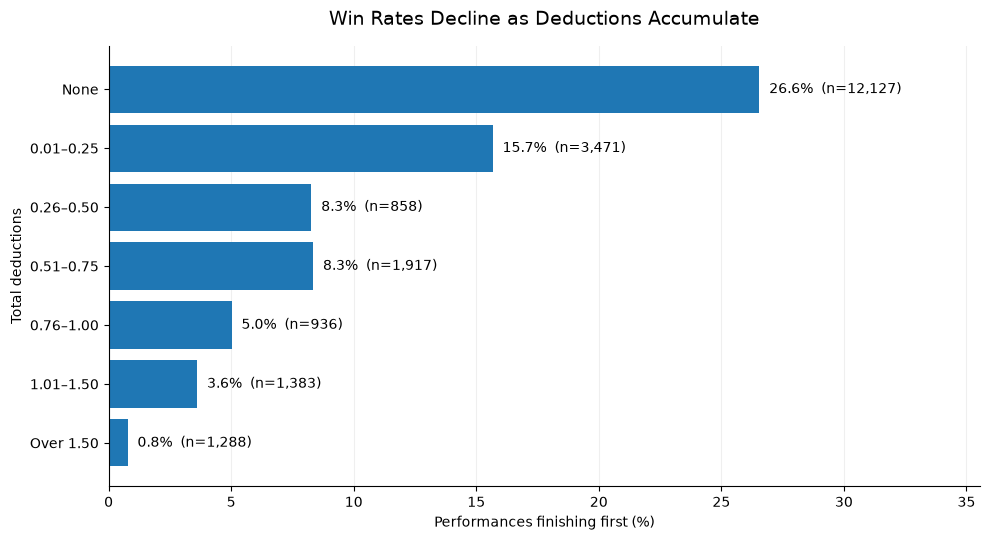

deduction_range  performances  wins  win_rate_pct
           None         12127  3220     26.552321
      0.01–0.25          3471   544     15.672717
      0.26–0.50           858    71      8.275058
      0.51–0.75          1917   160      8.346375
      0.76–1.00           936    47      5.021368
      1.01–1.50          1383    50      3.615329
      Over 1.50          1288    10      0.776398


In [17]:
deduction_bins = [-0.001, 0, 0.25, 0.50, 0.75, 1.00, 1.50, float("inf")]
deduction_labels = [
    "None", "0.01–0.25", "0.26–0.50", "0.51–0.75",
    "0.76–1.00", "1.01–1.50", "Over 1.50"
]

severity = eligible.copy()
severity["deduction_range"] = pd.cut(
    severity["deductions"],
    bins=deduction_bins,
    labels=deduction_labels
)

severity_rates = (
    severity.groupby("deduction_range", observed=True)
    .agg(
        performances=("rank", "size"),
        wins=("rank", lambda ranks: (ranks == 1).sum())
    )
    .reset_index()
)

severity_rates["win_rate_pct"] = (
    100 * severity_rates["wins"] / severity_rates["performances"]
)

fig, ax = plt.subplots(figsize=(10, 5.5))

bars = ax.barh(
    severity_rates["deduction_range"].astype(str),
    severity_rates["win_rate_pct"]
)

ax.invert_yaxis()  # No deductions at the top

for bar, rate, n in zip(
    bars,
    severity_rates["win_rate_pct"],
    severity_rates["performances"]
):
    ax.text(
        bar.get_width() + 0.4,
        bar.get_y() + bar.get_height() / 2,
        f"{rate:.1f}%  (n={n:,})",
        va="center",
        fontsize=10
    )

ax.set_title(
    "Win Rates Decline as Deductions Accumulate",
    fontsize=14,
    pad=15
)
ax.set_xlabel("Performances finishing first (%)")
ax.set_ylabel("Total deductions")
ax.set_xlim(0, severity_rates["win_rate_pct"].max() + 9)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

print(severity_rates.to_string(index=False))

### Finding: First-Place Finishes Become Less Common as Deductions Accumulate

Among performances in fields of at least three teams, 26.6% of deduction-free performances were recorded as rank 1. That figure was 15.7% for performances with 0.01–0.25 deductions, approximately 8.3% for those with 0.26–0.75 deductions, and 0.8% for those with more than 1.50 deductions.

**Takeaway for coaches:** Even small deductions are associated with fewer first-place finishes. The data does not show a distinct drop at exactly 0.75 points, so it would be misleading to describe a single stunt drop as a universal cutoff for finishing first.

**Important context:** These figures compare different performances, not the same routine with and without a deduction. They also group penalties by total points, not by the specific skill or mistake that caused them.

**Methodology note:** Placement is based on the rank published in Varsity’s results. Some division-round fields list more than one team as rank 1, so a rank-1 record does not necessarily represent a unique winner. All published ranks are retained without adjustment.

Counts: {'Would pass ≥1 opponent': 3700, 'Would only reach a tie': 221, 'Would neither pass nor tie': 5932}
Total deducted performances: 9853


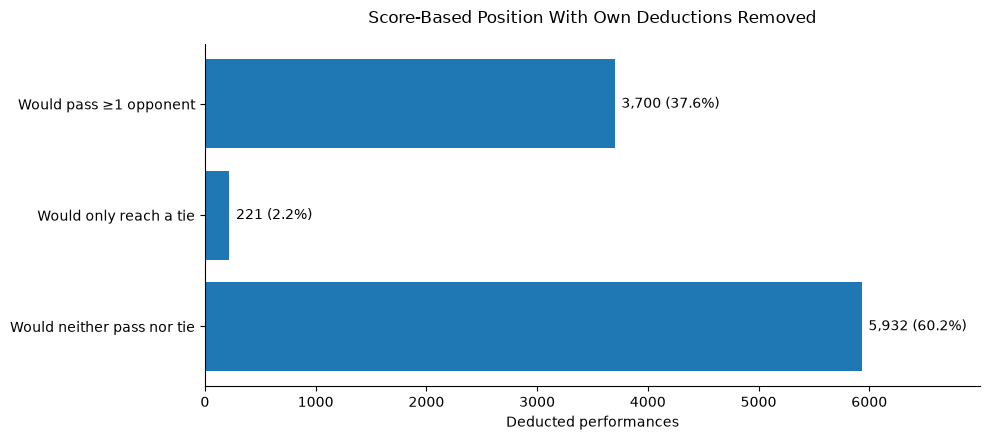

In [44]:
# Hypothetical effect of removing each team's own deductions.
# Opponents' recorded round scores remain unchanged.

import numpy as np

impact = eligible.copy()

impact["score_before_deductions"] = (
    impact["raw_score"] / impact["scorecard_max"] * 100
)
impact["score_after_deductions"] = (
    impact["score_before_deductions"] - impact["deductions"]
)

pass_count = 0
tie_only_count = 0
neither_count = 0

for _, field in impact.groupby(field_cols):
    scores = field["score_after_deductions"].to_numpy()

    for i, row in enumerate(field.itertuples(index=False)):
        if row.deductions <= 0:
            continue

        opponents = np.delete(scores, i)
        hypothetical = row.score_before_deductions
        actual = row.score_after_deductions

        would_pass = np.any(
            (opponents > actual) & (opponents < hypothetical)
        )
        would_tie = np.any(
            np.isclose(opponents, hypothetical, atol=0.0001, rtol=0)
        )

        if would_pass:
            pass_count += 1
        elif would_tie:
            tie_only_count += 1
        else:
            neither_count += 1

impact_counts = {
    "Would pass ≥1 opponent": pass_count,
    "Would only reach a tie": tie_only_count,
    "Would neither pass nor tie": neither_count,
}

total = sum(impact_counts.values())

print("Counts:", impact_counts)
print("Total deducted performances:", total)

fig, ax = plt.subplots(figsize=(10, 4.5))

bars = ax.barh(
    list(impact_counts.keys()),
    list(impact_counts.values()),
)

ax.invert_yaxis()
ax.set_xlim(0, max(impact_counts.values()) * 1.18)
ax.set_xlabel("Deducted performances")
ax.set_title(
    "Score-Based Position With Own Deductions Removed",
    pad=15,
)

for bar, count in zip(bars, impact_counts.values()):
    ax.text(
        bar.get_width() + 60,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,} ({count / total:.1%})",
        va="center",
    )

ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### Finding: Deductions Can Change Score-Based Position

Among 9,853 performances with deductions, 37.6% would pass at least one opponent if their own deductions were removed while all other recorded scores remained unchanged. Another 2.2% would reach a tie without passing an opponent.

**Takeaway for coaches:** Deductions can matter even when they do not appear to determine a team's final placement. The closer the scores, the more consequential a penalty may be.

**Important limitation:** This is a hypothetical comparison of individual-round scores, not a recalculation of official competition placements. A mistake such as a stunt drop may also reduce difficulty or execution scores. Because this analysis restores only the recorded deductions, it does not measure the full scoring impact of a mistake or predict what would have happened with a clean routine.

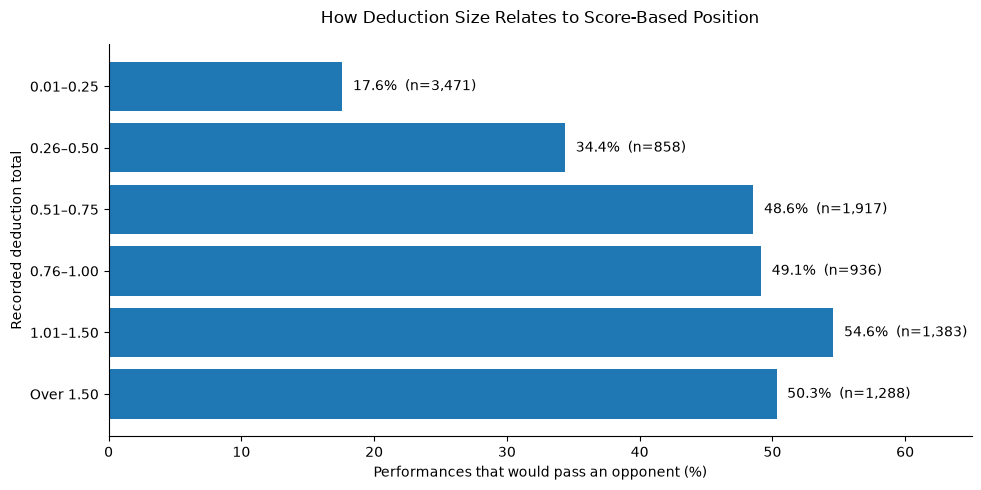

                 performances  would_pass  pass_pct
deduction_range                                    
0.01–0.25                3471         611      17.6
0.26–0.50                 858         295      34.4
0.51–0.75                1917         931      48.6
0.76–1.00                 936         460      49.1
1.01–1.50                1383         755      54.6
Over 1.50                1288         648      50.3


In [46]:
# Deduction size vs. hypothetical score-based position impact.
# Only each team's deduction is removed; opponents' scores stay unchanged.

import numpy as np

position_by_size = eligible.copy()

position_by_size["score_before"] = (
    position_by_size["raw_score"]
    / position_by_size["scorecard_max"]
    * 100
)
position_by_size["score_after"] = (
    position_by_size["score_before"]
    - position_by_size["deductions"]
)

position_by_size["would_pass"] = False

for _, field in position_by_size.groupby(field_cols):
    scores = field["score_after"].to_numpy()

    for i, row in enumerate(field.itertuples(index=False)):
        if row.deductions <= 0:
            continue

        opponents = np.delete(scores, i)

        would_pass = np.any(
            (opponents > row.score_after)
            & (opponents < row.score_before)
        )

        position_by_size.at[field.index[i], "would_pass"] = would_pass

deducted_by_size = position_by_size[
    position_by_size["deductions"] > 0
].copy()

deducted_by_size["deduction_range"] = pd.cut(
    deducted_by_size["deductions"],
    bins=[0, 0.25, 0.5, 0.75, 1, 1.5, float("inf")],
    labels=[
        "0.01–0.25",
        "0.26–0.50",
        "0.51–0.75",
        "0.76–1.00",
        "1.01–1.50",
        "Over 1.50",
    ],
)

summary = (
    deducted_by_size
    .groupby("deduction_range", observed=True)
    .agg(
        performances=("would_pass", "size"),
        would_pass=("would_pass", "sum"),
    )
)

summary["pass_pct"] = (
    summary["would_pass"] / summary["performances"] * 100
)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    summary.index.astype(str),
    summary["pass_pct"],
)

ax.invert_yaxis()
ax.set_xlim(0, 65)
ax.set_xlabel("Performances that would pass an opponent (%)")
ax.set_ylabel("Recorded deduction total")
ax.set_title(
    "How Deduction Size Relates to Score-Based Position",
    pad=15,
)

for bar, (_, row) in zip(bars, summary.iterrows()):
    ax.text(
        bar.get_width() + 0.8,
        bar.get_y() + bar.get_height() / 2,
        f"{row['pass_pct']:.1f}%  (n={int(row['performances']):,})",
        va="center",
    )

ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print(summary.round(1).to_string())


### Finding: Larger Deductions More Often Affect Score-Based Position

Removing a team's own deductions would allow it to pass at least one opponent in 17.6% of performances with 0.01–0.25 deductions. That rises to 48.6% for performances with 0.51–0.75 deductions and ranges from 49.1% to 54.6% across the remaining deduction ranges.

**Takeaway for coaches:** Larger deductions are more often consequential in a deduction-only score comparison, but even a small penalty can matter when teams' scores are close.

**Important limitation:** This analysis removes only the recorded deduction while holding every other score constant. A stunt drop or other mistake may also affect difficulty and execution scores. The chart therefore does not measure the full cost of a mistake or predict official placement changes.


### Coaching Context: Difficulty Is Not Equally Flexible Across Skills

As a routine builder, I can often add an extra tumbling pass to create a buffer if an athlete omits a skill or receives a deduction. Adding an extra stunt element is generally more difficult to incorporate and involves a different risk–reward tradeoff.

This experience offers a possible explanation for why tumbling difficulty varies very little between teams in the same field, while stunt difficulty varies more often. The dataset shows the scoring pattern, but it does not capture routine-construction decisions or establish why the pattern occurs.

In [53]:

# Compare category gaps between the top two round scores in each field.

top_two_gaps = []

for _, field in eligible.groupby(field_cols):
    ordered = field.sort_values("performance_score", ascending=False)

    first = ordered.iloc[0]
    second = ordered.iloc[1]

    # A tied score does not establish which performance scored higher.
    if abs(first["performance_score"] - second["performance_score"]) < 0.0001:
        continue

    gaps = {
        category: first[category] - second[category]
        for category in comparison_categories
    }
    gaps["round_score_margin"] = (
        first["performance_score"] - second["performance_score"]
    )
    top_two_gaps.append(gaps)

top_two_df = pd.DataFrame(top_two_gaps)

top_two_summary = pd.DataFrame({
    "mean_category_gap": top_two_df[comparison_categories].mean(),
    "higher_scoring_team_ahead_pct": (
        top_two_df[comparison_categories].gt(0.0001).mean() * 100
    ),
}).sort_values("mean_category_gap", ascending=False)

print("Fields with distinct top two scores:", len(top_two_df))
print(
    "Median round-score margin:",
    round(top_two_df["round_score_margin"].median(), 3)
)
print(top_two_summary.round(3).to_string())

Fields with distinct top two scores: 3988
Median round-score margin: 0.717
                              mean_category_gap  higher_scoring_team_ahead_pct
stunt_execution                           0.046                         47.342
pyramid_difficulty                        0.043                         46.815
pyramid_execution                         0.043                         44.659
running_tumbling_execution                0.042                         43.004
rc                                        0.036                         61.685
show                                      0.035                         60.256
standing_tumbling_execution               0.035                         39.769
dance_execution                           0.030                         37.939
jump_execution                            0.026                         36.459
dance_difficulty                          0.025                         34.027
formations_transitions                    0.013         

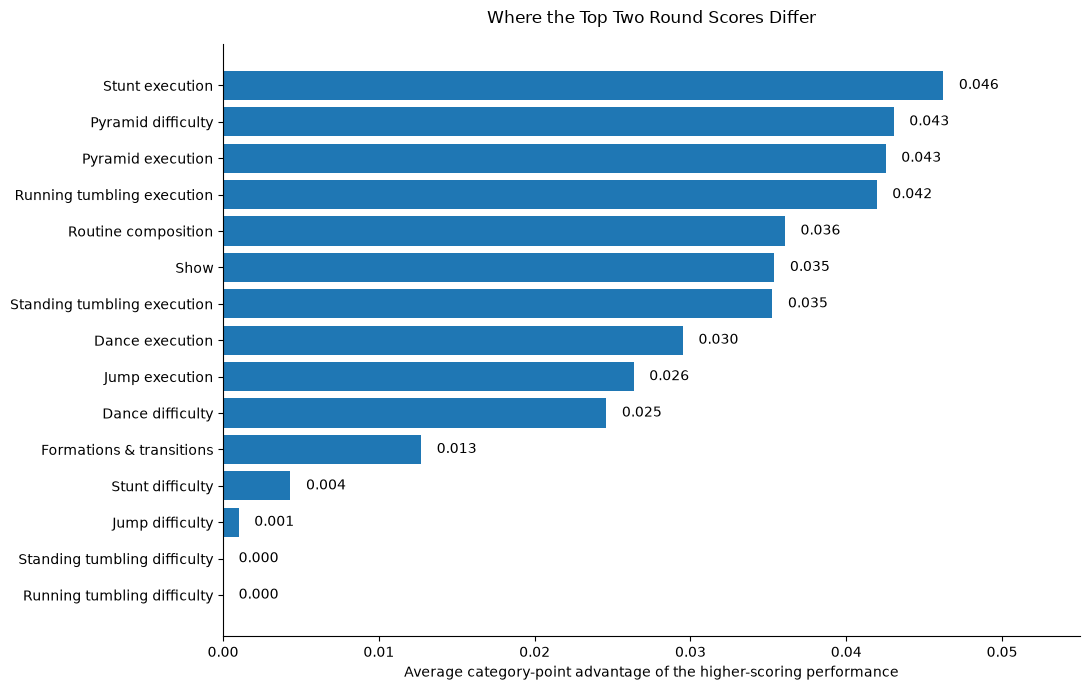

In [54]:

# Visualize average category gaps between the top two round scores.
# Positive values mean the higher-scoring performance averaged more points.

plot_data = (
    top_two_summary["mean_category_gap"]
    .sort_values()
    .rename(index={
        "stunt_execution": "Stunt execution",
        "pyramid_difficulty": "Pyramid difficulty",
        "pyramid_execution": "Pyramid execution",
        "running_tumbling_execution": "Running tumbling execution",
        "rc": "Routine composition",
        "show": "Show",
        "standing_tumbling_execution": "Standing tumbling execution",
        "dance_execution": "Dance execution",
        "jump_execution": "Jump execution",
        "dance_difficulty": "Dance difficulty",
        "formations_transitions": "Formations & transitions",
        "stunt_difficulty": "Stunt difficulty",
        "jump_difficulty": "Jump difficulty",
        "running_tumbling_difficulty": "Running tumbling difficulty",
        "standing_tumbling_difficulty": "Standing tumbling difficulty",
    })
)

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(plot_data.index, plot_data.values)

ax.set_title(
    "Where the Top Two Round Scores Differ",
    pad=15
)
ax.set_xlabel("Average category-point advantage of the higher-scoring performance")
ax.set_xlim(0, 0.055)

for bar in bars:
    ax.text(
        bar.get_width() + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.3f}",
        va="center"
    )

ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


### Finding: Execution Separates the Top Two Round Scores More Often Than Difficulty

Across 3,988 competition fields with distinct top-two round scores, the median difference between those scores was 0.717 points. The largest average category-point gaps were in stunt execution (0.046), pyramid difficulty (0.043), pyramid execution (0.043), and running tumbling execution (0.042).

Standing and running tumbling difficulty showed virtually no average gap between the top two performances. This is consistent with the coaching observation that teams can build tumbling difficulty buffers, although the dataset does not record how routines were constructed.

**Takeaway for coaches:** When teams have similar difficulty scores, execution and other scorecard details can distinguish their round scores. The results do not establish which skill a team should prioritize or what would happen if it changed its routine.

**Methodology:** This chart compares the two highest individual-round performance scores in each competition/division/round field, excluding tied top scores. It does not compare official placements or cumulative event scores. Values are average raw category-point differences, not normalized importance measures or causal effects. Toss categories are excluded because they do not apply to every scorecard.

In [55]:

# Compare category gaps in close versus wider top-two score contests.

close_cutoff = 0.5

close_contests = top_two_df[
    top_two_df["round_score_margin"] <= close_cutoff
]
wider_contests = top_two_df[
    top_two_df["round_score_margin"] > close_cutoff
]

comparison = pd.DataFrame({
    "close_mean_gap": close_contests[comparison_categories].mean(),
    "wider_mean_gap": wider_contests[comparison_categories].mean(),
    "close_ahead_pct": (
        close_contests[comparison_categories].gt(0.0001).mean() * 100
    ),
}).sort_values("close_mean_gap", ascending=False)

print(f"Close contests (≤ {close_cutoff} points): {len(close_contests):,}")
print(f"Wider contests (> {close_cutoff} points): {len(wider_contests):,}")
print("\nCategory differences:")
print(comparison.round(3).to_string())

Close contests (≤ 0.5 points): 1,487
Wider contests (> 0.5 points): 2,501

Category differences:
                              close_mean_gap  wider_mean_gap  close_ahead_pct
running_tumbling_execution             0.014           0.059           32.482
standing_tumbling_execution            0.012           0.049           30.330
stunt_execution                        0.011           0.067           34.028
pyramid_execution                      0.011           0.061           32.683
pyramid_difficulty                     0.011           0.062           33.692
show                                   0.010           0.051           43.107
dance_difficulty                       0.010           0.034           26.631
rc                                     0.009           0.052           45.864
dance_execution                        0.007           0.043           27.841
jump_execution                         0.006           0.038           26.900
formations_transitions                 0.002 


### Close-Contest Check: Small Advantages Add Up

In 1,487 fields where the top two individual-round scores differed by 0.5 points or less, the largest average category gaps were in running tumbling execution (0.014 points) and standing tumbling execution (0.012 points). No single category consistently favored the higher-scoring performance.

**Takeaway for coaches:** Close round scores can reflect small advantages spread across several categories rather than one decisive scorecard difference. A team can have the higher overall round score without leading in every category.

**Methodology:** The 0.5-point cutoff is an exploratory definition of a close contest, not an official competition standard. These are descriptive comparisons of round scores, not official placements or estimates of the effects of changing a routine.

In [56]:

# Check round names and whether teams have repeated performances
# within the same competition and division.

print("Round names:")
print(eligible["round"].value_counts().to_string())

team_event_cols = [
    "competition_id", "level", "division_id", "team_id"
]

team_round_counts = (
    eligible.groupby(team_event_cols)["round"]
    .nunique()
)

print("\nDistinct rounds per team within an event/division:")
print(team_round_counts.value_counts().sort_index().to_string())

print("\nTeams with more than one distinct round:",
      f"{(team_round_counts > 1).sum():,}")

Round names:
round
Finals        9411
Prelims       4667
Semifinals    4199
Round 1       1754
Round 2       1170
Wild Card      779

Distinct rounds per team within an event/division:
round
1    2210
2    9885

Teams with more than one distinct round: 9,885


In [60]:

# Check how deduction changes are distributed among matched teams.

deduction_change = changes["deduction_change"]

deduction_summary = pd.Series({
    "Fewer deductions in Finals": (deduction_change < -0.0001).sum(),
    "Same deductions": (deduction_change.abs() <= 0.0001).sum(),
    "More deductions in Finals": (deduction_change > 0.0001).sum(),
})

print("Deduction changes:")
print(deduction_summary.to_string())

print("\nPercentage of matched teams:")
print((deduction_summary / len(changes) * 100).round(1).to_string())

print("\nMedian score change by deduction direction:")
print(
    changes.assign(
        deduction_direction=pd.cut(
            changes["deduction_change"],
            bins=[-float("inf"), -0.0001, 0.0001, float("inf")],
            labels=["Fewer", "Same", "More"]
        )
    )
    .groupby("deduction_direction", observed=True)["round_score_change"]
    .median()
    .round(3)
    .to_string()
)

Deduction changes:
Fewer deductions in Finals    1613
Same deductions               1785
More deductions in Finals     1267

Percentage of matched teams:
Fewer deductions in Finals    34.6
Same deductions               38.3
More deductions in Finals     27.2

Median score change by deduction direction:
deduction_direction
Fewer    1.442
Same     0.507
More    -0.500



### Finding: Most Matched Teams Score Higher in Finals

Among 4,665 teams with both Prelims and Finals performances, 70.4% earned a higher individual-round score in Finals. The average score increased by 0.621 points: pre-deduction scores rose by an average of 0.549 points, while recorded deductions fell by an average of 0.071 points.

Only 34.6% of teams had fewer deductions in Finals; 38.3% had the same deduction total, and 27.2% had more. Teams with unchanged deductions still had a median round-score increase of 0.507 points.

**Takeaway for coaches:** A higher Finals score is not necessarily the result of fewer penalties. Changes in the pre-deduction score also matter.

**Methodology:** Teams are matched by competition, level, division, and team ID. This analysis compares individual-round scores, not cumulative event scores or official placement changes. The results describe observed differences between rounds; they do not establish whether routine changes, judging differences, or other factors caused those differences.

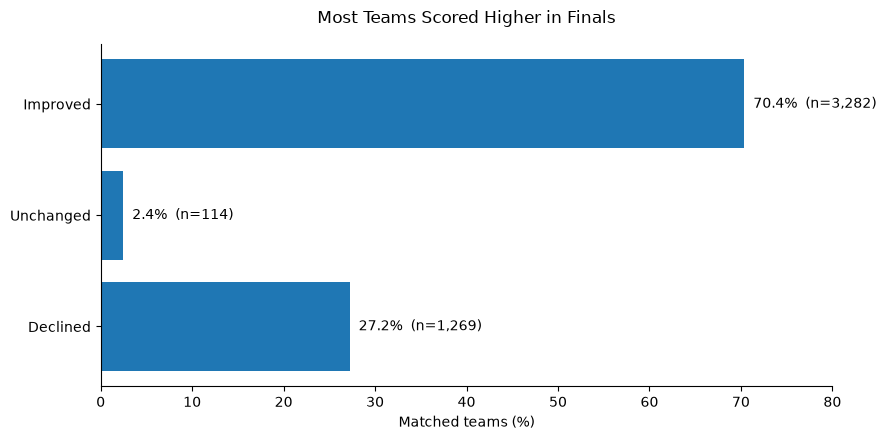

In [61]:

# Prelims → Finals: direction of individual-round score changes.
# Uses the matched-team "changes" dataframe from the analysis above.

score_change = changes["round_score_change"]

direction_counts = pd.Series({
    "Improved": (score_change > 0.0001).sum(),
    "Unchanged": (score_change.abs() <= 0.0001).sum(),
    "Declined": (score_change < -0.0001).sum(),
})

direction_pct = direction_counts / len(changes) * 100

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(direction_pct.index, direction_pct.values)

ax.invert_yaxis()
ax.set_xlim(0, 80)
ax.set_xlabel("Matched teams (%)")
ax.set_title(
    "Most Teams Scored Higher in Finals",
    pad=15
)

for bar, label in zip(bars, direction_counts.index):
    ax.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{direction_pct[label]:.1f}%  (n={direction_counts[label]:,})",
        va="center"
    )

ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()